<a href="https://colab.research.google.com/github/ZaenalAzidF/ZaenalAzidFaturohman_2306700078_uts-web2/blob/main/UAS_YOLO_2306700078_ZaenalAzidFaturohman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.3 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
from google.colab import files
import cv2
import pandas as pd
from collections import defaultdict


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
uploaded = files.upload()

Saving Video Project.mp4 to Video Project.mp4


In [4]:
model = YOLO("yolov8n.pt")

In [7]:
results = model.predict(
    source="/content/Video Project.mp4",
    conf=0.50,
    save=True,
    show=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/938) /content/Video Project.mp4: 384x640 3 cars, 1 tv, 356.3ms
video 1/1 (frame 2/938) /content/Video Project.mp4: 384x640 1 person, 3 cars, 1 truck, 1 tv, 216.0ms
video 1/1 (frame 3/938) /content/Video Project.mp4: 384x640 1 person, 2 cars, 1 truck, 156.1ms
video 1/1 (frame 4/938) /content/Video Project.mp4: 384x640 1 person, 2 cars, 1 truck, 130.7ms
video 1/1 (frame 5/938) /content/Video Project.mp4: 384x640 1 person, 2 cars, 1 truck

In [8]:
import os

output_folder = "runs/detect/predict"

print("Folder hasil:")
print(output_folder)

print("\nIsi folder:")
print(os.listdir(output_folder))

Folder hasil:
runs/detect/predict

Isi folder:
['Video Project.avi']


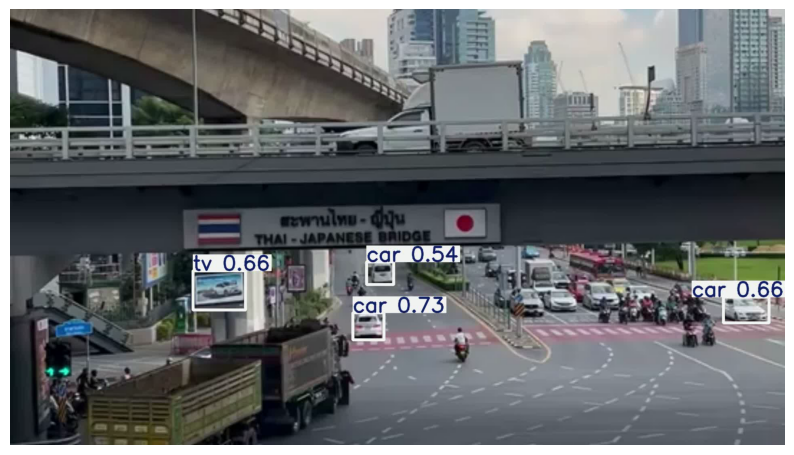

In [11]:
import cv2
import matplotlib.pyplot as plt

video_path = "/content/runs/detect/predict/Video Project.avi"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,6))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

cap.release()

In [15]:
from google.colab import files

files.download("/content/runs/detect/predict/Video Project.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from collections import defaultdict

objek = defaultdict(int)
conf_max = defaultdict(float)

for result in results:

    boxes = result.boxes

    for box in boxes:

        cls = int(box.cls[0])
        nama = model.names[cls]

        conf = float(box.conf[0])

        objek[nama] += 1

        if conf > conf_max[nama]:
            conf_max[nama] = conf

In [19]:
data = []

for nama in objek:

    data.append([
        nama,
        objek[nama],
        round(conf_max[nama],3)
    ])

df = pd.DataFrame(
    data,
    columns=[
        "Nama Objek",
        "Jumlah Kemunculan",
        "Confidence Tertinggi"
    ]
)

df.sort_values(
    by="Jumlah Kemunculan",
    ascending=False,
    inplace=True
)

df.head(5)

,Nama Objek,Jumlah Kemunculan,Confidence Tertinggi
0,car,4287,0.911
5,motorcycle,511,0.799
3,person,489,0.740
2,truck,206,0.863
4,bus,88,0.769
